In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1 : int
    operation : str
    number2 : int
    finalNumber : int
    

In [3]:
def adder(state:AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] + state['number2']
    return state

def subtractor(state:AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] - state['number2']
    return state

def decide_next_node(state:AgentState) -> str:
    if state['operation'] == 'add':
        return 'adder'
    elif state['operation'] == 'subtract':
        return 'subtractor'
    else:
        raise ValueError(f"Unknown operation: {state['operation']}")

In [4]:
graph = StateGraph(AgentState)
graph.add_node('router', lambda state: state)
graph.add_node('adder', adder)
graph.add_node('subtractor', subtractor)

graph.add_edge(START, 'router')
graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        'adder': 'adder',
        'subtractor': 'subtractor',
    },
)

graph.add_edge('adder', END)
graph.add_edge('subtractor', END)

app = graph.compile()

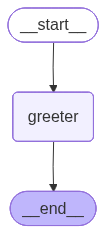

In [5]:
from IPython.display import display,Image 
display(Image(filename='graph.png'))

In [6]:
initial_state_1 = AgentState(number1=5, operation='add', number2=3, finalNumber=0)
print("Initial State 1:", initial_state_1)

Initial State 1: {'number1': 5, 'operation': 'add', 'number2': 3, 'finalNumber': 0}


In [7]:
from langgraph.graph import StateGraph,END 
import random 
from typing import TypedDict,Dict,Any,List,Tuple,Union

In [8]:
class AgentState(TypedDict): 
    name : str 
    number: List[int] 
    counter : int 
    

In [19]:
def greeting_node(state:AgentState) -> AgentState:
    state['name']=f'Hi there, I am agent {random.randint(1,100)}'
    state['counter'] = 0 
    return state

def random_number_node(state:AgentState) -> AgentState:
    state['number'].append(random.randint(1,100))
    state['counter'] += 1 
    return state 

def should_continue(state:AgentState) -> str:
    if state['counter'] < 5: 
        print(f"Counter is {state['counter']}, continuing...") 
        return 'random_number'
    else:
        print(f"Counter is {state['counter']}, stopping...") 
        return 'end'


In [20]:
graph = StateGraph(AgentState) 
graph.add_node('greeting', greeting_node) 
graph.add_node('random_number', random_number_node) 
graph.set_entry_point('greeting') 
graph.add_conditional_edges(
    'greeting',
    should_continue,
    {
        'random_number': 'random_number',
        'end': END
    }
)
graph.add_conditional_edges(
    'random_number',
    should_continue,
    {
        'random_number': 'random_number',
        'end': END
    }
)
app = graph.compile()
result = app.invoke({'name': '', 'number': [], 'counter': 0})
print('Final state:', result)


Counter is 0, continuing...
Counter is 1, continuing...
Counter is 2, continuing...
Counter is 3, continuing...
Counter is 4, continuing...
Counter is 5, stopping...
Final state: {'name': 'Hi there, I am agent 61', 'number': [69, 73, 60, 39, 70], 'counter': 5}


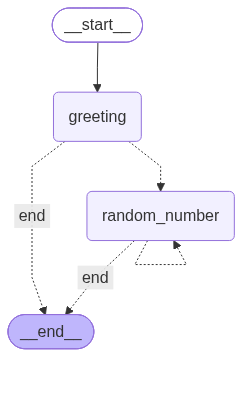

In [21]:
from IPython.display import display,Image 
display(Image(app.get_graph().draw_mermaid_png()))